# Music Recommender Evaluation

## 1. Setup

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocess import preprocess_pipeline
from src.embeddings import build_song_embeddings
from src.recommender import recommend
from src.baselines import BASELINES
from src.evaluate import (
    precision_at_k, recall_at_k, average_precision, ndcg_at_k,
    intra_list_diversity, novelty, gini_index, evaluate_all,
)
from src.test_set import TEST_PLAYLISTS, get_ground_truth_indices

TEXT_EMBEDDINGS_PATH = 'data/text_embeddings.npy'

print('Imports OK. Working dir:', os.getcwd())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding vibe anchors...
Vibe anchors ready.
Imports OK. Working dir: c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis


## 2. Load data, embeddings, and clusters

In [2]:
print('Preprocessing dataset (includes K-Means clustering)...')
df, audio_features, scaler, kmeans = preprocess_pipeline('data/spotify_data.csv')

if os.path.exists(TEXT_EMBEDDINGS_PATH):
    print('Loading cached text embeddings...')
    text_embeddings = np.load(TEXT_EMBEDDINGS_PATH)
else:
    print('Building text embeddings (this can take a while)...')
    _, text_embeddings = build_song_embeddings(df, audio_features)
    np.save(TEXT_EMBEDDINGS_PATH, text_embeddings)

SONG_EMBEDDINGS_PATH = 'data/song_embeddings.npy'
if os.path.exists(SONG_EMBEDDINGS_PATH):
    print('Loading cached 396-dim hstack embeddings...')
    song_embeddings = np.load(SONG_EMBEDDINGS_PATH)
else:
    print('Building 396-dim hstack embeddings (one-off)...')
    song_embeddings = np.hstack([audio_features, text_embeddings]).astype(np.float32)
    np.save(SONG_EMBEDDINGS_PATH, song_embeddings)

print()
print(f'Songs:                  {len(df):>10,}')
print(f'Genres:                 {df["genre"].nunique():>10,}')
print(f'Artists:                {df["artist_name"].nunique():>10,}')
print(f'Clusters (k):           {len(set(df["cluster"])):>10,}')
print(f'Text embedding dim:     {text_embeddings.shape[1]:>10,}')
print(f'Hstack embedding dim:   {song_embeddings.shape[1]:>10,}')

Preprocessing dataset (includes K-Means clustering)...
Loading cached text embeddings...
Loading cached 396-dim hstack embeddings...

Songs:                   1,159,748
Genres:                         82
Artists:                    64,158
Clusters (k):                   20
Text embedding dim:            384
Hstack embedding dim:          396


## 2.5 Train (or load) the custom audio encoder

In [3]:
from src.custom_encoder import train_or_load

custom_encoder, custom_info, custom_embeddings = train_or_load(
    df, audio_features,
    model_path='models/custom_encoder.pt',
    emb_path='data/custom_audio_embeddings.npy',
    epochs=15,
    batch_size=1024,
    verbose=True,
)

print()
print(f'Custom encoder ready.')
print(f'  Genres in classifier head: {custom_info["n_genres"]}')
print(f'  Embedding dim:             {custom_embeddings.shape[1]}')
print(f'  Cached embeddings:         {custom_embeddings.shape}')
if 'final_val_acc' in custom_info:
    print(f'  Final validation accuracy: {custom_info["final_val_acc"]:.4f}')
    print(f'  Random-baseline accuracy:  {1.0/custom_info["n_genres"]:.4f}')


Custom encoder ready.
  Genres in classifier head: 82
  Embedding dim:             32
  Cached embeddings:         (1159748, 32)


## 3. Test set summary

In [4]:
rows = []
for tp in TEST_PLAYLISTS:
    gt = get_ground_truth_indices(df, tp)
    rows.append({'Playlist': tp['name'], 'Ground-truth size': len(gt)})

test_summary = pd.DataFrame(rows)
test_summary

,Playlist,Ground-truth size
0,Heavy Metal,68024
1,Workout,72249
2,Sad Songs,46613
3,Hip Hop,15703
4,Acoustic Chill,70208
5,Club Night,129015
6,Sleep Music,72935
7,Punk Rock,13283
8,Jazz Blues,35625
9,Country Drive,34053


## 4. Run all systems on every test playlist

In [5]:
import time

TOP_K = 10

def hybrid_full(playlist_name, df, text_embeddings, top_k=10, **kwargs):
    return recommend(
        playlist_name, df, text_embeddings,
        top_k=top_k,
        scaler=kwargs.get('scaler'),
        kmeans=kwargs.get('kmeans'),
    )

ALL_SYSTEMS = {**BASELINES, 'hybrid_full': hybrid_full}

results = {name: {} for name in ALL_SYSTEMS}

for sys_name, sys_fn in ALL_SYSTEMS.items():
    t0 = time.time()
    for tp in TEST_PLAYLISTS:
        recs, _ = sys_fn(
            tp['name'], df, text_embeddings,
            top_k=TOP_K,
            scaler=scaler, kmeans=kmeans,
            custom_encoder=custom_encoder, custom_embeddings=custom_embeddings,
            song_embeddings=song_embeddings,
        )
        results[sys_name][tp['name']] = recs.index.tolist()
    print(f'{sys_name:15} done in {time.time() - t0:.1f}s')

print()
print('All recommendations collected.')

random          done in 4.0s
popularity      done in 0.6s
genre_only      done in 26.9s


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

audio_only      done in 33.4s
text_only       done in 57.2s


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

custom_nn       done in 5.0s


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

hstack_cosine   done in 49.8s


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

hybrid_full     done in 74.2s

All recommendations collected.


## 5. Compute metrics

In [6]:
metrics_rows = []
rec_counts = {name: np.zeros(len(df)) for name in ALL_SYSTEMS}
popularity_proxy = df['artist_freq'].values

for sys_name in ALL_SYSTEMS:
    precs, recs_, aps, ndcgs, ilds, novs = [], [], [], [], [], []

    for tp in TEST_PLAYLISTS:
        recommended = results[sys_name][tp['name']]
        relevant = list(get_ground_truth_indices(df, tp))

        precs.append(precision_at_k(recommended, relevant, TOP_K))
        recs_.append(recall_at_k(recommended, relevant, TOP_K))
        aps.append(average_precision(recommended, relevant))
        ndcgs.append(ndcg_at_k(recommended, relevant, TOP_K))
        ilds.append(intra_list_diversity(recommended, text_embeddings))
        novs.append(novelty(recommended, popularity_proxy))

        for idx in recommended:
            rec_counts[sys_name][idx] += 1

    metrics_rows.append({
        'System':       sys_name,
        'Precision@10': float(np.mean(precs)),
        'Recall@10':    float(np.mean(recs_)),
        'MAP':          float(np.mean(aps)),
        'NDCG@10':      float(np.mean(ndcgs)),
        'ILD':          float(np.mean(ilds)),
        'Novelty':      float(np.mean(novs)),
        'Gini':         gini_index(rec_counts[sys_name]),
    })

results_df = pd.DataFrame(metrics_rows).set_index('System')
print('Done.')

Done.


### Same metrics, computed with 

In [7]:
metrics_rows_v2 = []

for sys_name in ALL_SYSTEMS:
    per_playlist_metrics = []

    for tp in TEST_PLAYLISTS:
        recommended = results[sys_name][tp['name']]
        relevant = list(get_ground_truth_indices(df, tp))

        m = evaluate_all(
            recommended, relevant, k=TOP_K,
            embeddings=text_embeddings,
            popularity=popularity_proxy,
        )
        per_playlist_metrics.append(m)

    avg = pd.DataFrame(per_playlist_metrics).mean()
    metrics_rows_v2.append({
        'System':       sys_name,
        'Precision@10': avg['precision@10'],
        'Recall@10':    avg['recall@10'],
        'MAP':          avg['AP'],
        'NDCG@10':      avg['NDCG@10'],
        'ILD':          avg['ILD'],
        'Novelty':      avg['Novelty'],
        'Gini':         gini_index(rec_counts[sys_name]),
    })

results_df_v2 = pd.DataFrame(metrics_rows_v2).set_index('System')
results_df_v2.round(4)

,Precision@10,Recall@10,MAP,NDCG@10,ILD,Novelty,Gini
System,,,,,,,
random,0.0533,0.0000,0.0000,0.0606,0.8521,14.4894,1.0000
popularity,0.0600,0.0000,0.0000,0.0614,0.6993,15.1947,1.0000
genre_only,0.3267,0.0001,0.0000,0.3358,0.7641,14.3974,0.9999
audio_only,0.4933,0.0001,0.0001,0.5030,0.7124,14.3281,0.9999
text_only,0.6667,0.0002,0.0002,0.6665,0.3731,14.8836,0.9999
custom_nn,0.2000,0.0000,0.0000,0.1898,0.7746,14.3613,0.9999
hstack_cosine,0.5200,0.0001,0.0001,0.5443,0.6375,14.3178,0.9999
hybrid_full,0.8733,0.0002,0.0002,0.8685,0.5409,14.9579,0.9999


## 6. Comparison table

In [8]:
results_df.round(4)

,Precision@10,Recall@10,MAP,NDCG@10,ILD,Novelty,Gini
System,,,,,,,
random,0.0533,0.0000,0.0000,0.0606,0.8521,14.4894,1.0000
popularity,0.0600,0.0000,0.0000,0.0614,0.6993,15.1947,1.0000
genre_only,0.3267,0.0001,0.0000,0.3358,0.7641,14.3974,0.9999
audio_only,0.4933,0.0001,0.0001,0.5030,0.7124,14.3281,0.9999
text_only,0.6667,0.0002,0.0002,0.6665,0.3731,14.8836,0.9999
custom_nn,0.2000,0.0000,0.0000,0.1898,0.7746,14.3613,0.9999
hstack_cosine,0.5200,0.0001,0.0001,0.5443,0.6375,14.3178,0.9999
hybrid_full,0.8733,0.0002,0.0002,0.8685,0.5409,14.9579,0.9999


In [9]:
higher_better = ['Precision@10', 'Recall@10', 'MAP', 'NDCG@10', 'ILD', 'Novelty']
lower_better = ['Gini']

(results_df.round(4)
    .style
    .background_gradient(cmap='Greens', subset=higher_better, axis=0)
    .background_gradient(cmap='Greens_r', subset=lower_better, axis=0))

,Precision@10,Recall@10,MAP,NDCG@10,ILD,Novelty,Gini
System,,,,,,,
random,0.053300,0.000000,0.000000,0.060600,0.852100,14.489400,1.000000
popularity,0.060000,0.000000,0.000000,0.061400,0.699300,15.194700,1.000000
genre_only,0.326700,0.000100,0.000000,0.335800,0.764100,14.397400,0.999900
audio_only,0.493300,0.000100,0.000100,0.503000,0.712400,14.328100,0.999900
text_only,0.666700,0.000200,0.000200,0.666500,0.373100,14.883600,0.999900
custom_nn,0.200000,0.000000,0.000000,0.189800,0.774600,14.361300,0.999900
hstack_cosine,0.520000,0.000100,0.000100,0.544300,0.637500,14.317800,0.999900
hybrid_full,0.873300,0.000200,0.000200,0.868500,0.540900,14.957900,0.999900


## 7. Bar chart comparison per metric

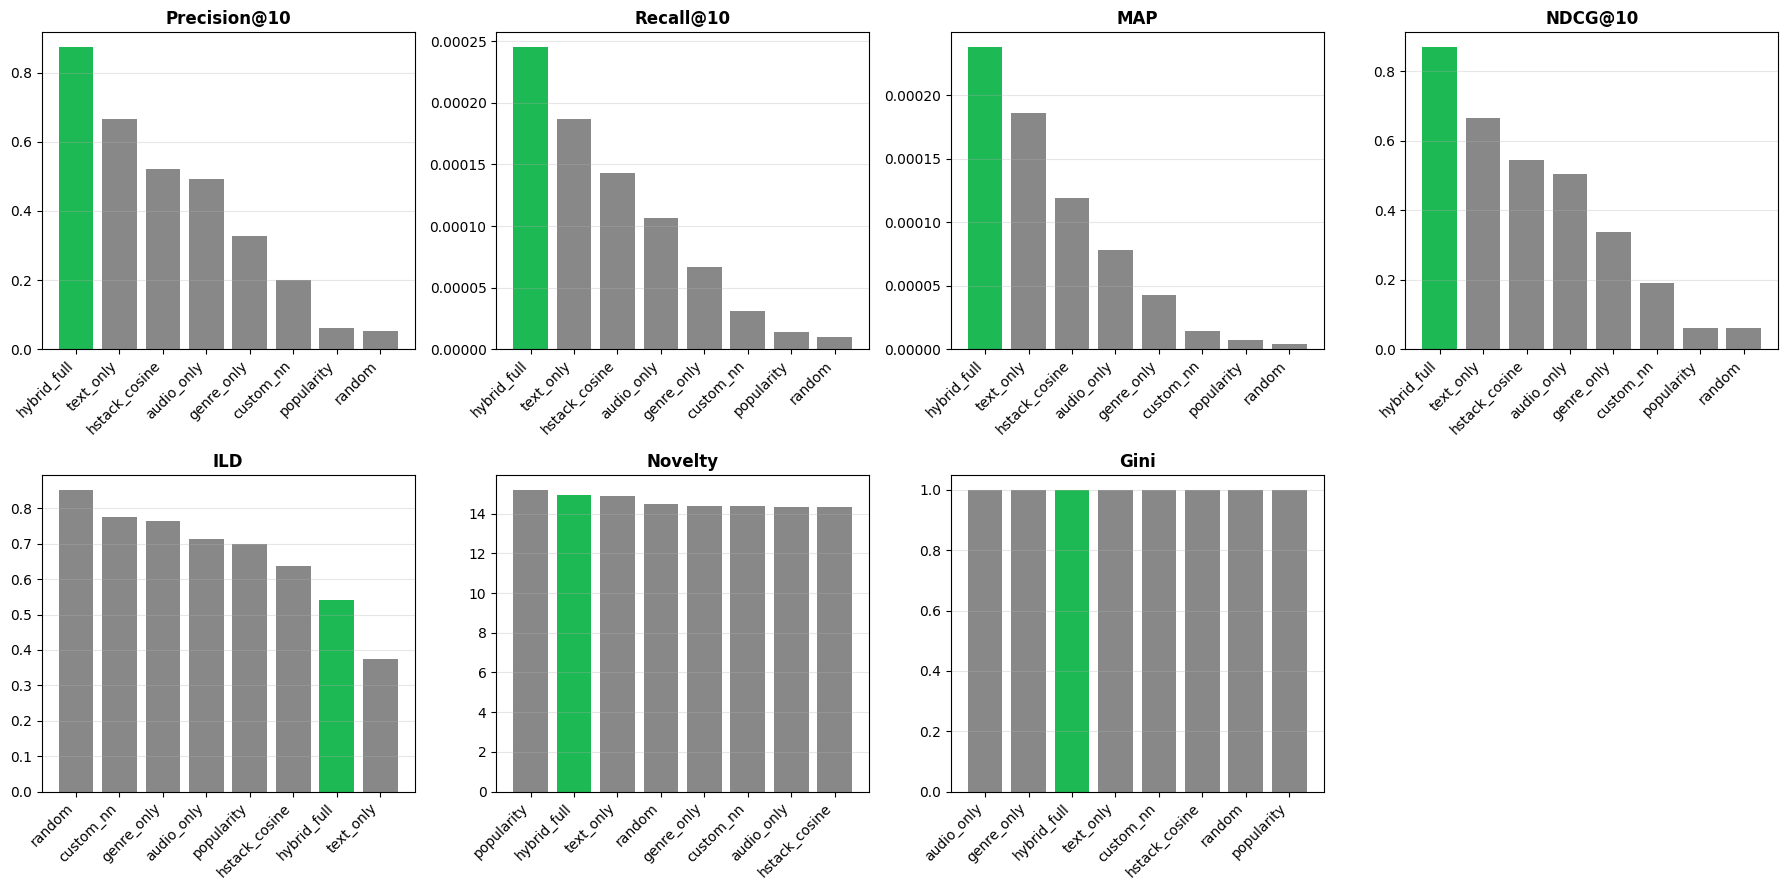

In [10]:
metrics_to_plot = ['Precision@10', 'Recall@10', 'MAP', 'NDCG@10', 'ILD', 'Novelty', 'Gini']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flat

for ax, metric in zip(axes, metrics_to_plot):
    ascending = metric == 'Gini'
    sorted_df = results_df.sort_values(metric, ascending=ascending)
    colors = ['#1db954' if name == 'hybrid_full' else '#888888' for name in sorted_df.index]
    ax.bar(sorted_df.index, sorted_df[metric], color=colors)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.grid(axis='y', alpha=0.3)

axes[7].axis('off')
plt.tight_layout()
plt.show()

## 8. Per-playlist precision

In [11]:
per_playlist = {sys_name: [] for sys_name in ALL_SYSTEMS}
playlist_names = [tp['name'] for tp in TEST_PLAYLISTS]

for tp in TEST_PLAYLISTS:
    relevant = list(get_ground_truth_indices(df, tp))
    for sys_name in ALL_SYSTEMS:
        recommended = results[sys_name][tp['name']]
        per_playlist[sys_name].append(precision_at_k(recommended, relevant, TOP_K))

per_playlist_df = pd.DataFrame(per_playlist, index=playlist_names)
per_playlist_df.round(2)

,random,popularity,genre_only,audio_only,text_only,custom_nn,hstack_cosine,hybrid_full
Heavy Metal,0.0,0.0,0.2,0.8,1.0,0.2,1.0,1.0
Workout,0.0,0.0,0.4,0.5,0.0,0.5,0.1,0.1
Sad Songs,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.4
Hip Hop,0.0,0.2,0.1,0.4,1.0,0.1,0.8,1.0
Acoustic Chill,0.2,0.0,0.0,0.0,1.0,0.1,0.8,1.0
Club Night,0.0,0.0,0.2,0.9,0.9,0.9,0.3,0.9
Sleep Music,0.1,0.0,0.5,1.0,1.0,0.3,0.9,1.0
Punk Rock,0.0,0.0,0.0,0.2,1.0,0.0,0.6,1.0
Jazz Blues,0.0,0.0,0.7,0.6,1.0,0.1,0.8,1.0
Country Drive,0.2,0.0,0.4,0.2,1.0,0.0,0.7,1.0


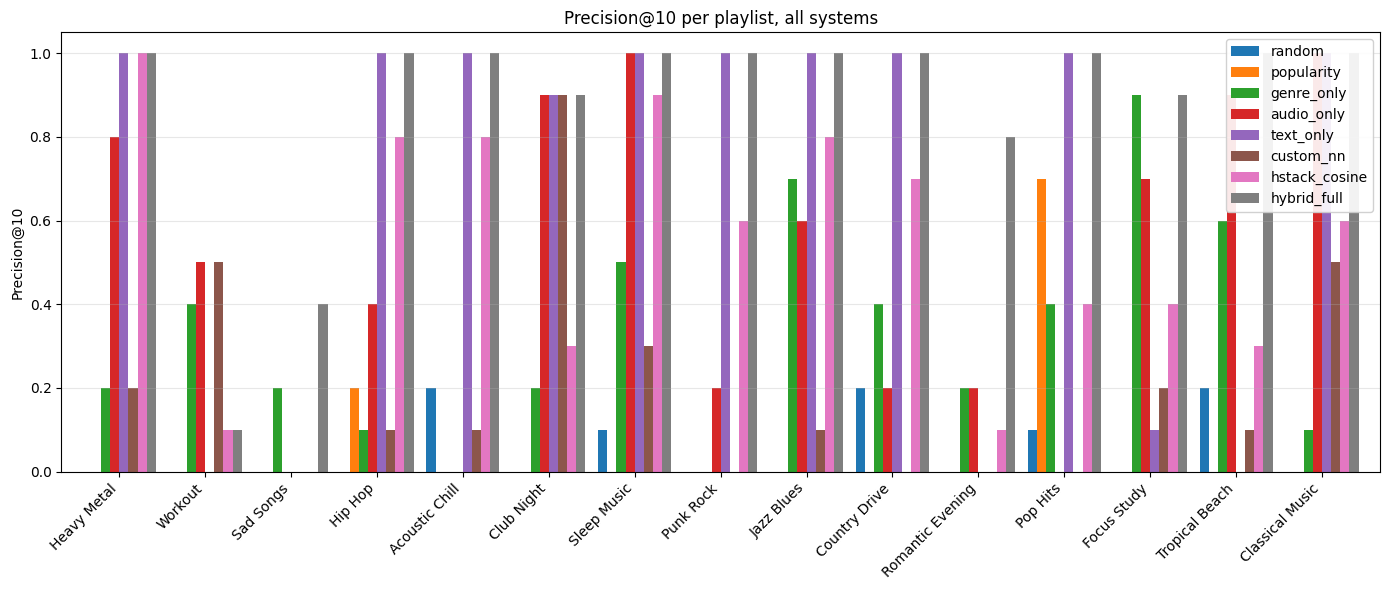

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
per_playlist_df.plot(kind='bar', ax=ax, width=0.85)
ax.set_ylabel('Precision@10')
ax.set_title('Precision@10 per playlist, all systems')
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Held-out validation

In [13]:
from src.test_set import HELD_OUT_PLAYLISTS

held_out_results = {name: {} for name in ALL_SYSTEMS}
held_out_precs = {name: [] for name in ALL_SYSTEMS}
held_out_per_playlist = {name: [] for name in ALL_SYSTEMS}
held_out_names = [tp['name'] for tp in HELD_OUT_PLAYLISTS]

for sys_name, sys_fn in ALL_SYSTEMS.items():
    for tp in HELD_OUT_PLAYLISTS:
        recs, _ = sys_fn(
            tp['name'], df, text_embeddings,
            top_k=TOP_K,
            scaler=scaler, kmeans=kmeans,
            custom_encoder=custom_encoder, custom_embeddings=custom_embeddings,
            song_embeddings=song_embeddings,
        )
        recommended = recs.index.tolist()
        held_out_results[sys_name][tp['name']] = recommended

        relevant = list(get_ground_truth_indices(df, tp))
        p = precision_at_k(recommended, relevant, TOP_K)
        held_out_precs[sys_name].append(p)
        held_out_per_playlist[sys_name].append(p)
    print(f'{sys_name:15} held-out done')

held_out_df = pd.DataFrame({
    'Held-out Prec@10': {s: float(np.mean(v)) for s, v in held_out_precs.items()},
}).round(4)

held_out_per_playlist_df = pd.DataFrame(held_out_per_playlist, index=held_out_names)
held_out_per_playlist_df.round(2)

random          held-out done
popularity      held-out done
genre_only      held-out done


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

audio_only      held-out done
text_only       held-out done


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

custom_nn       held-out done


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

hstack_cosine   held-out done


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

hybrid_full     held-out done


,random,popularity,genre_only,audio_only,text_only,custom_nn,hstack_cosine,hybrid_full
Headbanger Anthems,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.0
Gym Beast Mode,0.0,0.0,0.1,0.4,0.2,0.6,0.4,0.2
Heartbreak Hour,0.0,0.0,0.2,0.0,0.4,0.0,0.0,0.3
Trap Bangers,0.0,0.2,0.1,0.4,0.4,0.1,0.1,0.6
Coffee Shop,0.2,0.0,0.2,0.2,0.0,0.1,0.0,0.0
Dance Floor,0.0,0.0,0.2,0.9,0.2,0.9,0.2,0.0
Bedtime,0.1,0.0,0.5,1.0,1.0,0.3,0.9,1.0
Mosh Pit,0.0,0.0,0.1,0.1,0.0,0.1,0.0,0.1
Smoky Lounge,0.0,0.0,0.7,0.6,0.2,0.1,0.4,0.7
Highway Cruise,0.2,0.0,0.0,0.0,0.1,0.1,0.0,0.0


In [14]:
comparison = pd.DataFrame({
    'Dev Prec@10':       results_df['Precision@10'],
    'Held-out Prec@10':  held_out_df['Held-out Prec@10'],
})
comparison['Gap (Dev - Held-out)'] = (comparison['Dev Prec@10'] - comparison['Held-out Prec@10']).round(4)
comparison.round(4)

,Dev Prec@10,Held-out Prec@10,Gap (Dev - Held-out)
random,0.0533,0.0533,0.0000
popularity,0.0600,0.0600,-0.0000
genre_only,0.3267,0.1800,0.1467
audio_only,0.4933,0.3000,0.1933
text_only,0.6667,0.2133,0.4534
custom_nn,0.2000,0.1667,0.0333
hstack_cosine,0.5200,0.1400,0.3800
hybrid_full,0.8733,0.2400,0.6333


### Interpreting the gap

## 9.1 Full held-out metrics

In [15]:
held_out_metrics_rows = []
held_out_rec_counts = {name: np.zeros(len(df)) for name in ALL_SYSTEMS}

for sys_name in ALL_SYSTEMS:
    precs, recs_, aps, ndcgs, ilds, novs = [], [], [], [], [], []
    for tp in HELD_OUT_PLAYLISTS:
        recommended = held_out_results[sys_name][tp['name']]
        relevant = list(get_ground_truth_indices(df, tp))
        precs.append(precision_at_k(recommended, relevant, TOP_K))
        recs_.append(recall_at_k(recommended, relevant, TOP_K))
        aps.append(average_precision(recommended, relevant))
        ndcgs.append(ndcg_at_k(recommended, relevant, TOP_K))
        ilds.append(intra_list_diversity(recommended, text_embeddings))
        novs.append(novelty(recommended, popularity_proxy))
        for idx in recommended:
            held_out_rec_counts[sys_name][idx] += 1
    held_out_metrics_rows.append({
        'System':       sys_name,
        'Precision@10': float(np.mean(precs)),
        'Recall@10':    float(np.mean(recs_)),
        'MAP':          float(np.mean(aps)),
        'NDCG@10':      float(np.mean(ndcgs)),
        'ILD':          float(np.mean(ilds)),
        'Novelty':      float(np.mean(novs)),
        'Gini':         gini_index(held_out_rec_counts[sys_name]),
    })

held_out_full_df = pd.DataFrame(held_out_metrics_rows).set_index('System')
held_out_full_df.round(4)

,Precision@10,Recall@10,MAP,NDCG@10,ILD,Novelty,Gini
System,,,,,,,
random,0.0533,0.0000,0.0,0.0606,0.8521,14.4894,1.0000
popularity,0.0600,0.0000,0.0,0.0614,0.6993,15.1947,1.0000
genre_only,0.1800,0.0000,0.0,0.1931,0.7649,14.7458,0.9999
audio_only,0.3000,0.0001,0.0,0.3124,0.7218,14.6121,0.9999
text_only,0.2133,0.0000,0.0,0.2020,0.4283,14.7862,0.9999
custom_nn,0.1667,0.0000,0.0,0.1682,0.7676,14.9922,0.9999
hstack_cosine,0.1400,0.0000,0.0,0.1405,0.6657,14.9817,0.9999
hybrid_full,0.2400,0.0001,0.0,0.2423,0.5685,14.5211,0.9999


## 9.7 Hit Rate@10

In [16]:
import numpy as np
import pandas as pd

def hit_rate_at_k(per_playlist_dict):
    out = {}
    for sys_name, p_values in per_playlist_dict.items():
        arr = np.asarray(p_values, dtype=float)
        out[sys_name] = float((arr > 0).mean()) if len(arr) > 0 else 0.0
    return out

dev_hit_rate    = hit_rate_at_k(per_playlist)
held_hit_rate   = hit_rate_at_k(held_out_per_playlist)

hit_rate_df = pd.DataFrame({
    'HitRate@10 (dev)':       pd.Series(dev_hit_rate),
    'HitRate@10 (held-out)':  pd.Series(held_hit_rate),
}).round(3)

hit_rate_df = hit_rate_df.sort_values('HitRate@10 (dev)', ascending=False)

print('Hit Rate@10 — fraction of playlists where the system found at least one relevant song:')
print()
hit_rate_df

Hit Rate@10 — fraction of playlists where the system found at least one relevant song:



,HitRate@10 (dev),HitRate@10 (held-out)
hybrid_full,1.000,0.533
hstack_cosine,0.933,0.400
genre_only,0.867,0.600
audio_only,0.800,0.533
text_only,0.733,0.667
custom_nn,0.667,0.667
random,0.333,0.333
popularity,0.133,0.133


## 9.2 Statistical significance

In [17]:
from scipy.stats import wilcoxon

baselines_to_test = [s for s in ALL_SYSTEMS if s != 'hybrid_full']
hybrid_scores = np.array(held_out_per_playlist['hybrid_full'])

sig_rows = []
for b in baselines_to_test:
    other = np.array(held_out_per_playlist[b])
    diff = hybrid_scores - other
    if np.all(diff == 0):
        stat, p = float('nan'), 1.0
    else:
        stat, p = wilcoxon(hybrid_scores, other,
                           zero_method='wilcox', alternative='greater')
    sig_rows.append({
        'Baseline':              b,
        'Hybrid mean':           float(np.mean(hybrid_scores)),
        'Baseline mean':         float(np.mean(other)),
        'Mean diff':             float(np.mean(diff)),
        'p-value':               float(p),
        'Significant (p<0.05)':  bool(p < 0.05),
    })

sig_df = pd.DataFrame(sig_rows).set_index('Baseline')
sig_df.round(4)

,Hybrid mean,Baseline mean,Mean diff,p-value,Significant (p<0.05)
Baseline,,,,,
random,0.24,0.0533,0.1867,0.0304,True
popularity,0.24,0.0600,0.1800,0.0375,True
genre_only,0.24,0.1800,0.0600,0.1977,False
audio_only,0.24,0.3000,-0.0600,0.7999,False
text_only,0.24,0.2133,0.0267,0.5000,False
custom_nn,0.24,0.1667,0.0733,0.2237,False
hstack_cosine,0.24,0.1400,0.1000,0.0837,False


## 9.3 Failure analysis

In [18]:
from src.recommender import interpret_playlist as _interpret_for_inspect

hybrid_per_playlist_held = pd.Series(
    held_out_per_playlist['hybrid_full'], index=held_out_names
).sort_values()

worst_3 = hybrid_per_playlist_held.head(3)

print('Worst 3 held-out playlists for hybrid_full:')
print(worst_3.round(3).to_string())
print()

for name in worst_3.index:
    tp = next(p for p in HELD_OUT_PLAYLISTS if p['name'] == name)
    interp = _interpret_for_inspect(name)
    relevant = list(get_ground_truth_indices(df, tp))
    recommended = held_out_results['hybrid_full'][name]
    overlap = len(set(recommended) & set(relevant))

    print(f'--- {name} ---')
    print(f'  Ground-truth pool size:                {len(relevant):,}')
    print(f'  Recommendations matching ground truth: {overlap}/{TOP_K}')
    print(f'  Matched anchors: {interp["matched_anchors"]}')
    print(f'  Target genres:   {interp["genres"]}')
    print()

Worst 3 held-out playlists for hybrid_full:
Headbanger Anthems    0.0
Coffee Shop           0.0
Dance Floor           0.0

--- Headbanger Anthems ---
  Ground-truth pool size:                68,024
  Recommendations matching ground truth: 0/10
  Matched anchors: ['hip hop rap', 'pop hits happy upbeat fun party celebration euphoric joyful chart mainstream', 'tropical shore summer atmosphere reggae dancehall afrobeat']
  Target genres:   ['hip-hop', 'rap', 'trap', 'dancehall', 'groove', 'funk', 'pop', 'party', 'dance', 'disco', 'club', 'afrobeat', 'reggae', 'dub', 'samba', 'salsa', 'ska']

--- Coffee Shop ---
  Ground-truth pool size:                70,208
  Recommendations matching ground truth: 0/10
  Matched anchors: ['morning espresso sunday breakfast chill positive fresh start', 'hip hop rap', 'club midnight groove rhythm track electronic rave techno house bpm dancing']
  Target genres:   ['acoustic', 'folk', 'singer-songwriter', 'indie-pop', 'soul', 'jazz', 'pop', 'hip-hop', 'rap',

## 9.6 Full anchor routing diagnostic

In [19]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from src.vibes import VIBE_ANCHORS
from src.recommender import interpret_playlist
from src.test_set import TEST_PLAYLISTS, HELD_OUT_PLAYLISTS

_diag_model = SentenceTransformer('all-MiniLM-L6-v2')
_diag_descs = [a['description'] for a in VIBE_ANCHORS]
_diag_embs = _diag_model.encode(_diag_descs, show_progress_bar=False)

DOMINANCE_MARGIN = 0.025

def diagnose_routing(playlist_name, top_n=3, max_desc=70):
    interp = interpret_playlist(playlist_name)
    q_emb = _diag_model.encode([playlist_name])
    sims = cosine_similarity(q_emb, _diag_embs)[0]
    sorted_idx = sims.argsort()[::-1]

    matched = interp['matched_anchors']
    weights = interp['anchor_weights']
    margin = sims[sorted_idx[0]] - sims[sorted_idx[1]]
    mode = 'TOP-1 SELECTED' if margin >= DOMINANCE_MARGIN else f'BLENDED top {len(matched)}'

    print(f"\n{'=' * 90}")
    print(f"  PLAYLIST: {playlist_name!r}")
    print(f"{'=' * 90}")
    print(f"\n  Routed to ({len(matched)} anchor{'s' if len(matched) > 1 else ''} | margin={margin:.4f} → {mode}):")
    for desc, w in zip(matched, weights):
        short = desc[:max_desc] + '...' if len(desc) > max_desc else desc
        print(f"    [{w:.3f}] {short}")
    print(f"\n  Allowed genres ({len(interp['genres'])}): {interp['genres'][:8]}{'...' if len(interp['genres']) > 8 else ''}")
    if interp.get('year_range'):
        print(f"  Year range: {interp['year_range']}")
    print(f"\n  Top {top_n} anchor candidates by similarity:")
    for rank, idx in enumerate(sorted_idx[:top_n], 1):
        d = _diag_descs[idx]
        short = d[:60] + '...' if len(d) > 60 else d
        marker = '→' if rank == 1 else ' '
        print(f"    {marker} #{idx+1:2d} sim={sims[idx]:.4f} | {short}")

print('\n' + '█' * 90)
print('  DEVELOPMENT SET (15 playlists)')
print('█' * 90)
for pl in TEST_PLAYLISTS:
    diagnose_routing(pl['name'])

print('\n\n' + '█' * 90)
print('  HELD-OUT SET (15 playlists)')
print('█' * 90)
for pl in HELD_OUT_PLAYLISTS:
    diagnose_routing(pl['name'])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



██████████████████████████████████████████████████████████████████████████████████████████
  DEVELOPMENT SET (15 playlists)
██████████████████████████████████████████████████████████████████████████████████████████

  PLAYLIST: 'Heavy Metal'

  Routed to (1 anchor | margin=0.2113 → TOP-1 SELECTED):
    [1.000] aggressive angry heavy metal hardcore rage intense

  Allowed genres (9): ['metal', 'heavy-metal', 'black-metal', 'death-metal', 'hardcore', 'grindcore', 'metalcore', 'hard-rock']...

  Top 3 anchor candidates by similarity:
    → # 1 sim=0.5821 | aggressive angry heavy metal hardcore rage intense
      #14 sim=0.3708 | punk rebellious fast loud raw DIY underground alternative
      #10 sim=0.3469 | hip hop rap

  PLAYLIST: 'Workout'

  Routed to (1 anchor | margin=0.0532 → TOP-1 SELECTED):
    [1.000] workout training fitness running exercise pump power energy

  Allowed genres (8): ['edm', 'hardstyle', 'electronic', 'hip-hop', 'rock', 'hard-rock', 'drum-and-bass', 'dance']
  Y

### Routing summary table

In [20]:
summary_rows = []
for pl_set, set_name in [(TEST_PLAYLISTS, 'dev'), (HELD_OUT_PLAYLISTS, 'held-out')]:
    for pl in pl_set:
        name = pl['name']
        interp = interpret_playlist(name)
        q_emb = _diag_model.encode([name])
        sims = cosine_similarity(q_emb, _diag_embs)[0]
        sorted_idx = sims.argsort()[::-1]
        margin = sims[sorted_idx[0]] - sims[sorted_idx[1]]

        top_anchor_idx = sorted_idx[0] + 1
        top_anchor_desc = _diag_descs[sorted_idx[0]][:45] + '...'
        n_blended = len(interp['matched_anchors'])
        summary_rows.append({
            'set': set_name,
            'playlist': name,
            'anchor_#': top_anchor_idx,
            'anchor_description (truncated)': top_anchor_desc,
            'sim': round(sims[sorted_idx[0]], 4),
            'margin': round(margin, 4),
            'mode': f'top-1' if margin >= DOMINANCE_MARGIN else f'blended (×{n_blended})',
        })

routing_summary_df = pd.DataFrame(summary_rows)
routing_summary_df

,set,playlist,anchor_#,anchor_description (truncated),sim,margin,mode
0,dev,Heavy Metal,1,aggressive angry heavy metal hardcore rage in...,0.5821,0.2113,top-1
1,dev,Workout,5,workout training fitness running exercise pum...,0.3847,0.0532,top-1
2,dev,Sad Songs,4,sad melancholic emotional lovesick lonely dep...,0.5433,0.1428,top-1
3,dev,Hip Hop,10,hip hop rap...,0.9206,0.4641,top-1
4,dev,Acoustic Chill,16,tropical shore summer atmosphere reggae dance...,0.4029,0.0249,blended (×3)
5,dev,Club Night,7,club midnight groove rhythm track electronic ...,0.4291,0.0526,top-1
6,dev,Sleep Music,2,calm peaceful relaxing sleep ambient quiet so...,0.5497,0.1182,top-1
7,dev,Punk Rock,14,punk rebellious fast loud raw DIY underground...,0.5918,0.0824,top-1
8,dev,Jazz Blues,13,jazz blues soul smooth classic vintage mellow...,0.6622,0.2725,top-1
9,dev,Country Drive,12,country folk western americana road trip guit...,0.4052,0.1843,top-1


## 9.4 Ablation: before vs. after the four bug fixes

In [21]:
import copy
from sklearn.metrics.pairwise import cosine_similarity as _cos

from src.recommender import (
    model as _st_model,
    score_songs_by_year, get_relevant_clusters,
    AUDIO_FEATURES, FEATURE_RANGES,
)
from src.vibes import VIBE_ANCHORS
from src.embeddings import create_playlist_embedding

_LEGACY_ANCHORS = copy.deepcopy(VIBE_ANCHORS)
for a in _LEGACY_ANCHORS:
    if 'pop hits' in a['description']:
        a['description'] = 'happy upbeat fun party celebration euphoric joyful'
    elif 'club night dance floor' in a['description']:
        a['description'] = 'club banger electronic rave'
        a['features']['instrumentalness'] = 0.6

_legacy_anchor_emb = _st_model.encode(
    [a['description'] for a in _LEGACY_ANCHORS], show_progress_bar=False
)


def _interpret_legacy(playlist_name):
    vec = _st_model.encode([playlist_name])
    sims = _cos(vec, _legacy_anchor_emb)[0]
    top_idx = sims.argsort()[::-1][:3]
    top_scores = sims[top_idx]
    weights = np.exp(top_scores) / np.exp(top_scores).sum()

    blended = {f: sum(weights[i] * _LEGACY_ANCHORS[top_idx[i]]['features'][f]
                      for i in range(3))
               for f in AUDIO_FEATURES}
    genre_scores = {}
    for i in range(3):
        for g in _LEGACY_ANCHORS[top_idx[i]]['genres']:
            genre_scores[g] = genre_scores.get(g, 0) + weights[i]
    allowed = [g for g, s in genre_scores.items() if s > 0.1]
    return {
        'features':   blended,
        'genres':     allowed,
        'year_range': _LEGACY_ANCHORS[top_idx[0]].get('year_range'),
    }


def _score_legacy(df, target_features, allowed_genres,
                  relevant_clusters=None, year_range=None):
    feat_scores = np.zeros(len(df))
    for feature, target_val in target_features.items():
        if feature not in df.columns:
            continue
        if feature == 'key':
            diff = np.abs(df[feature].values.astype(float) - target_val)
            closeness = 1.0 - np.minimum(diff, 12.0 - diff) / 6.0
        elif feature not in FEATURE_RANGES:
            continue
        else:
            fmin = FEATURE_RANGES[feature]['min']
            frange = FEATURE_RANGES[feature]['max'] - fmin
            closeness = 1.0 - np.abs(
                ((df[feature].values - fmin) / frange) - ((target_val - fmin) / frange)
            )
        feat_scores += closeness
    feat_scores /= len(target_features)

    keywords = set()
    for g in allowed_genres:
        for part in g.replace('-', ' ').split():
            if len(part) > 3:
                keywords.add(part)
    if keywords:
        pattern = '|'.join(keywords)
        genre_mask = df['genre'].str.contains(pattern, case=False, na=False).values.astype(float)
    else:
        genre_mask = df['genre'].isin(allowed_genres).values.astype(float)

    has_clusters = relevant_clusters is not None and 'cluster' in df.columns
    has_year = year_range is not None and 'year' in df.columns
    cluster_mask = df['cluster'].isin(relevant_clusters).values.astype(float) if has_clusters else None
    year_scores = score_songs_by_year(df, year_range) if has_year else None

    if has_clusters and has_year:
        return 0.45 * feat_scores + 0.20 * genre_mask + 0.17 * cluster_mask + 0.18 * year_scores
    elif has_clusters:
        return 0.55 * feat_scores + 0.25 * genre_mask + 0.20 * cluster_mask
    elif has_year:
        return 0.60 * feat_scores + 0.25 * genre_mask + 0.15 * year_scores
    else:
        return 0.70 * feat_scores + 0.30 * genre_mask


def hybrid_full_legacy(playlist_name, df, text_embeddings, top_k=10,
                       scaler=None, kmeans=None, **kw):
    interp = _interpret_legacy(playlist_name)
    rel_clusters = (get_relevant_clusters(interp['features'], scaler, kmeans)
                    if scaler is not None and kmeans is not None else None)
    audio_scores = _score_legacy(df, interp['features'], interp['genres'],
                                  rel_clusters, interp['year_range'])
    text_vec = create_playlist_embedding(playlist_name)
    text_sim = _cos(text_vec, text_embeddings)[0]
    text_norm = (text_sim - text_sim.min()) / (text_sim.max() - text_sim.min() + 1e-8)
    final_scores = 0.6 * audio_scores + 0.4 * text_norm
    top = final_scores.argsort()[-top_k:][::-1]
    return df.iloc[top].assign(score=final_scores[top].round(3)), {}


legacy_precs = []
for tp in HELD_OUT_PLAYLISTS:
    recs, _ = hybrid_full_legacy(tp['name'], df, text_embeddings,
                                  top_k=TOP_K, scaler=scaler, kmeans=kmeans)
    relevant = list(get_ground_truth_indices(df, tp))
    legacy_precs.append(precision_at_k(recs.index.tolist(), relevant, TOP_K))

after_mean  = float(np.mean(held_out_per_playlist['hybrid_full']))
before_mean = float(np.mean(legacy_precs))

ablation_df = pd.DataFrame([
    {'System': 'hybrid_full (before fixes)', 'Held-out Prec@10': before_mean},
    {'System': 'hybrid_full (after fixes)',  'Held-out Prec@10': after_mean},
    {'System': 'Improvement (delta)',        'Held-out Prec@10': after_mean - before_mean},
]).set_index('System')
ablation_df.round(4)

c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

,Held-out Prec@10
System,
hybrid_full (before fixes),0.1333
hybrid_full (after fixes),0.2400
Improvement (delta),0.1067


## 9.5 Ablation: hand-crafted vs. cluster-derived anchors

In [22]:
from src.recommender import score_songs_by_audio


def build_cluster_anchors(df, scaler, kmeans, top_genres_per_cluster=4):
    centroids_std = kmeans.cluster_centers_
    centroids_raw = scaler.inverse_transform(centroids_std)

    anchors = []
    for c in range(kmeans.n_clusters):
        members = df[df['cluster'] == c]
        if len(members) == 0:
            continue
        top_genres = members['genre'].value_counts().head(top_genres_per_cluster).index.tolist()
        feats = {f: float(centroids_raw[c, i]) for i, f in enumerate(AUDIO_FEATURES)}

        descriptors = []
        if feats['energy']       >= 0.7: descriptors.append('high-energy')
        elif feats['energy']     <= 0.3: descriptors.append('low-energy calm')
        if feats['danceability'] >= 0.7: descriptors.append('danceable')
        if feats['valence']      >= 0.7: descriptors.append('happy upbeat')
        elif feats['valence']    <= 0.3: descriptors.append('sad melancholic')
        if feats['acousticness'] >= 0.6: descriptors.append('acoustic')
        if feats['instrumentalness'] >= 0.5: descriptors.append('instrumental')
        if feats['speechiness']  >= 0.2: descriptors.append('vocal-heavy')
        if feats['tempo']        >= 140: descriptors.append('fast tempo')
        elif feats['tempo']      <= 80:  descriptors.append('slow tempo')

        description = ' '.join(descriptors + top_genres).strip() or ' '.join(top_genres)
        anchors.append({
            'description': description,
            'genres':      top_genres,
            'year_range':  None,
            'features':    feats,
            'cluster_id':  c,
        })
    return anchors


_CLUSTER_ANCHORS = build_cluster_anchors(df, scaler, kmeans)
print(f'Discovered {len(_CLUSTER_ANCHORS)} cluster-anchors (one per K-Means cluster)\n')
for a in _CLUSTER_ANCHORS[:5]:
    print(f"  cluster {a['cluster_id']:>2}: {a['description']}")
print('  ...')

_cluster_anchor_emb = _st_model.encode(
    [a['description'] for a in _CLUSTER_ANCHORS], show_progress_bar=False
)


def _interpret_clusters(playlist_name, top_n_anchors=3, dominance_margin=0.025):
    vec = _st_model.encode([playlist_name])
    sims = _cos(vec, _cluster_anchor_emb)[0]
    sorted_idx = sims.argsort()[::-1]
    top_score = sims[sorted_idx[0]]
    second = sims[sorted_idx[1]] if len(sorted_idx) > 1 else 0.0
    effective_n = 1 if (top_score - second) >= dominance_margin else top_n_anchors

    top_idx = sorted_idx[:effective_n]
    top_scores = sims[top_idx]
    weights = np.exp(top_scores) / np.exp(top_scores).sum()

    blended = {f: sum(weights[i] * _CLUSTER_ANCHORS[top_idx[i]]['features'][f]
                      for i in range(effective_n))
               for f in AUDIO_FEATURES}
    genre_scores = {}
    for i in range(effective_n):
        for g in _CLUSTER_ANCHORS[top_idx[i]]['genres']:
            genre_scores[g] = genre_scores.get(g, 0) + weights[i]
    allowed = [g for g, s in genre_scores.items() if s > 0.1]
    return {
        'features':        blended,
        'genres':          allowed,
        'matched_anchors': [_CLUSTER_ANCHORS[top_idx[i]]['description'] for i in range(effective_n)],
    }


def hybrid_full_clusters(playlist_name, df, text_embeddings, top_k=10,
                         scaler=None, kmeans=None, **kw):
    interp = _interpret_clusters(playlist_name)
    rel_clusters = (get_relevant_clusters(interp['features'], scaler, kmeans)
                    if scaler is not None and kmeans is not None else None)
    audio_scores = score_songs_by_audio(
        df, interp['features'], interp['genres'],
        rel_clusters, year_range=None,
    )
    text_vec = create_playlist_embedding(playlist_name)
    text_sim = _cos(text_vec, text_embeddings)[0]
    text_norm = (text_sim - text_sim.min()) / (text_sim.max() - text_sim.min() + 1e-8)
    final_scores = 0.6 * audio_scores + 0.4 * text_norm
    top = final_scores.argsort()[-top_k:][::-1]
    return df.iloc[top].assign(score=final_scores[top].round(3)), interp


cluster_precs = []
for tp in HELD_OUT_PLAYLISTS:
    recs, _ = hybrid_full_clusters(tp['name'], df, text_embeddings,
                                    top_k=TOP_K, scaler=scaler, kmeans=kmeans)
    relevant = list(get_ground_truth_indices(df, tp))
    cluster_precs.append(precision_at_k(recs.index.tolist(), relevant, TOP_K))

handcrafted_mean = float(np.mean(held_out_per_playlist['hybrid_full']))
cluster_mean     = float(np.mean(cluster_precs))

anchor_ablation_df = pd.DataFrame([
    {'System': 'hybrid_full (cluster-derived anchors)', 'Held-out Prec@10': cluster_mean},
    {'System': 'hybrid_full (hand-crafted anchors)',    'Held-out Prec@10': handcrafted_mean},
    {'System': 'Hand-crafted advantage (delta)',        'Held-out Prec@10': handcrafted_mean - cluster_mean},
]).set_index('System')
anchor_ablation_df.round(4)

Discovered 20 cluster-anchors (one per K-Means cluster)

  cluster  0: high-energy emo alt-rock power-pop death-metal
  cluster  1: high-energy sad melancholic instrumental black-metal grindcore death-metal drum-and-bass
  cluster  2: vocal-heavy dancehall hip-hop hardcore funk
  cluster  3: high-energy danceable happy upbeat salsa k-pop forro dancehall
  cluster  4: high-energy instrumental minimal-techno deep-house breakbeat drum-and-bass
  ...


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

,Held-out Prec@10
System,
hybrid_full (cluster-derived anchors),0.0933
hybrid_full (hand-crafted anchors),0.2400
Hand-crafted advantage (delta),0.1467


## 10. Sample inspection

In [23]:
SAMPLE_PLAYLIST = 'Heavy Metal'
print(f"=== '{SAMPLE_PLAYLIST}' ===\n")
for sys_name in ALL_SYSTEMS:
    print(f'--- {sys_name} ---')
    indices = results[sys_name][SAMPLE_PLAYLIST]
    for i, idx in enumerate(indices, 1):
        row = df.iloc[idx]
        track = str(row['track_name'])[:40]
        artist = str(row['artist_name'])[:25]
        print(f'  {i:2}. {track:40} \u2013 {artist:25} [{row["genre"]}]')
    print()

=== 'Heavy Metal' ===

--- random ---
   1. Benza, Deus - Ao Vivo                    – Moacyr Luz e Samba do Tra [samba]
   2. Best Of All Possible Worlds              – The Little Willies        [folk]
   3. Right in Two                             – Twinkle Twinkle Little Ro [sleep]
   4. Bomb Intro / Pass That Dutch             – Missy Elliott             [dance]
   5. Sunrise                                  – John Mark Pantana         [indie-pop]
   6. Fake and Poser Kill                      – Takafumi Matsubara        [grindcore]
   7. Maybe She                                – Arthur Russell            [folk]
   8. Ire Omo                                  – Tony Allen                [afrobeat]
   9. Viver uma Paixão / Desejo / De Bandeja   – Banda Magníficos          [forro]
  10. Responsibles                             – The Red Chord             [grindcore]

--- popularity ---
   1. Flowers                                  – Miley Cyrus               [pop]
   2. Shakira: Bzr

## 11. Embedding space visualisation

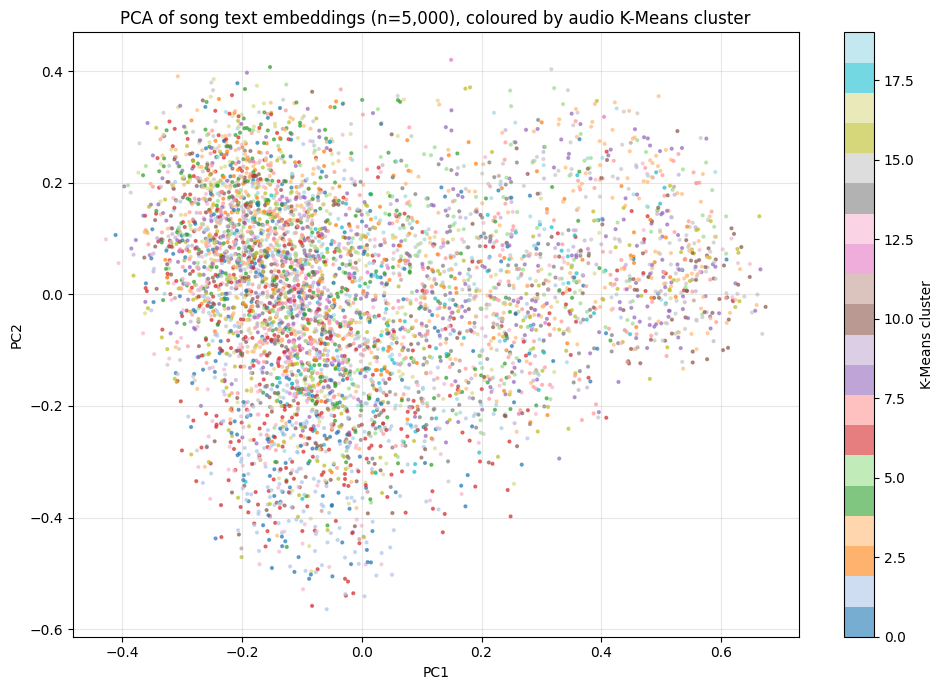

In [24]:
from sklearn.decomposition import PCA

SAMPLE_SIZE = 5000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), size=SAMPLE_SIZE, replace=False)

pca = PCA(n_components=2, random_state=42)
pts = pca.fit_transform(text_embeddings[sample_idx])
labels = df['cluster'].values[sample_idx]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pts[:, 0], pts[:, 1], c=labels, cmap='tab20', s=4, alpha=0.6)
plt.colorbar(scatter, label='K-Means cluster')
plt.title(f'PCA of song text embeddings (n={SAMPLE_SIZE:,}), coloured by audio K-Means cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Notes for the thesis